# Attention

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
from transformers import AddedToken, AutoModelForSeq2SeqLM, AutoTokenizer
from bertviz_local import head_view, generation_view

device = (torch.accelerator.current_accelerator()
          if torch.accelerator.is_available() else torch.device('cpu'))
print('Device:', device)

Device: xpu


## 2. Cross-attention: German → English

The same mechanism also translates natural language. We use a pretrained **Marian** encoder–decoder model: the encoder reads the German sentence, and the decoder generates English one token at a time. No training is needed; the first run downloads another model. Run the setup and `inspect_translation` cells above first.

Try **Ich habe gestern ein Buch gelesen.** (roughly **I read a book yesterday.**). German puts `gelesen` near the end, while English usually puts `read` earlier. Cross-attention can look anywhere in the German input, even when the two languages use different word orders.

- **Queries (Q):** English decoder states, representing the output prefix.
- **Keys and values (K, V):** contextual German encoder states.
- **Attention:** `softmax(Q @ K.T / sqrt(d_k)) @ V` blends German information into each decoder state. The next-token prediction also uses the rest of the decoder—not attention alone.

In [2]:
TRANSLATION_MODEL_ID = 'Helsinki-NLP/opus-mt-de-en'
tokenizer = AutoTokenizer.from_pretrained(TRANSLATION_MODEL_ID)
model = AutoModelForSeq2SeqLM.from_pretrained(
    TRANSLATION_MODEL_ID, attn_implementation='eager').to(device).eval()


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

In [3]:
@torch.inference_mode()
def inspect_translation(source_code, max_new_tokens=128, *, model=model, tokenizer=tokenizer):
    if max_new_tokens < 1:
        raise ValueError('max_new_tokens must be positive')
    inputs = tokenizer(source_code, return_tensors='pt').to(device)
    if inputs['input_ids'].shape[1] > 256:
        raise ValueError('Use a short input (at most 256 source tokens) for this visualization.')
    model.eval()
    generated_ids = model.generate(
        **inputs, max_new_tokens=max_new_tokens, do_sample=False, num_beams=1)
    decoder_ids = generated_ids[:, :-1]
    outputs = model(
        **inputs, decoder_input_ids=decoder_ids,
        decoder_attention_mask=torch.ones_like(decoder_ids),
        output_attentions=True, use_cache=False)
    def cpu_layers(layers):
        if not layers or any(layer is None for layer in layers):
            raise RuntimeError('Attention weights are missing; load the model with eager attention.')
        return tuple(layer.detach().cpu() for layer in layers)
    return {
        'translation': tokenizer.decode(generated_ids[0], skip_special_tokens=True),
        'generated_ids': generated_ids.cpu(),
        'encoder_tokens': tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].tolist()),
        'decoder_tokens': tokenizer.convert_ids_to_tokens(decoder_ids[0].tolist()),
        'predicted_tokens': tokenizer.convert_ids_to_tokens(generated_ids[0, 1:].tolist()),
        'encoder_attention': cpu_layers(outputs.encoder_attentions),
        'decoder_attention': cpu_layers(outputs.decoder_attentions),
        'cross_attention': cpu_layers(outputs.cross_attentions),
    }

In [4]:
german_text = 'Ich habe gestern ein Buch gelesen.'
# Try: 'Die Katze sitzt auf der Matte.'
german_example = inspect_translation(
    german_text, max_new_tokens=64,
)
print('German:', german_text)
print('Generated English:', german_example['translation'])
print('Cross-attention [batch, heads, English queries, German keys]:',
      german_example['cross_attention'][0].shape)
if german_example['generated_ids'][0, -1].item() != model.config.eos_token_id:
    print('Token budget reached before EOS; increase max_new_tokens.')

[transformers] Both `max_new_tokens` (=64) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


German: Ich habe gestern ein Buch gelesen.
Generated English: I read a book yesterday.
Cross-attention [batch, heads, English queries, German keys]: torch.Size([1, 8, 7, 8])


### Explore the connections

In the **Cross** view, English decoder input tokens are on the left and German source tokens are on the right. Switch layers and heads; look for connections around `Buch` / `book` and `gelesen` / `read`. These are things to investigate, not guaranteed alignments in every head. `▁` marks a word boundary, and a word may be split into several subword tokens.

Remember the **one-token shift** from the code example: a row labeled `I` uses a prefix ending in `I` to predict the *next* token, not `I` itself. The first row is the decoder-start token (Marian uses `<pad>`); it predicts the first English token and remains unmasked. The heatmap below labels each row with both its query token and its next-token prediction.

Use the dropdown to compare **Encoder** (German → German), **Decoder** (English prefix → English prefix, causally masked), and **Cross** (English → the full German input). Attention weights show information routing, not proof of why a word was chosen.

In [5]:
head_view(
    encoder_attention=german_example['encoder_attention'],
    decoder_attention=german_example['decoder_attention'],
    cross_attention=german_example['cross_attention'],
    encoder_tokens=german_example['encoder_tokens'],
    decoder_tokens=german_example['decoder_tokens'],
    layer=3, heads=[2])

### Watch generation: read → predict → append

Use **Next** to read the current decoder prefix, reveal its next-token prediction, then append that token. The next step reads the extended prefix to predict again. **Play** advances automatically; **Back**, **Reset**, and the step slider let you inspect any point.

The highlighted final query predicts the next token. **Decoder** attention can read only the prefix available at this step; **Cross** attention can still read the entire German source. No future decoder tokens are shown in the attention diagram. An appended token enters that diagram when it is read at the next step.

This replays the sequence already generated above, using the causal attention recorded in the replay pass—not a new model run or a live probability display. The last token (EOS, or the token-budget endpoint) is appended but has no later query row in this recording.

In [8]:
generation_view(german_example, layer=3, heads=[2])

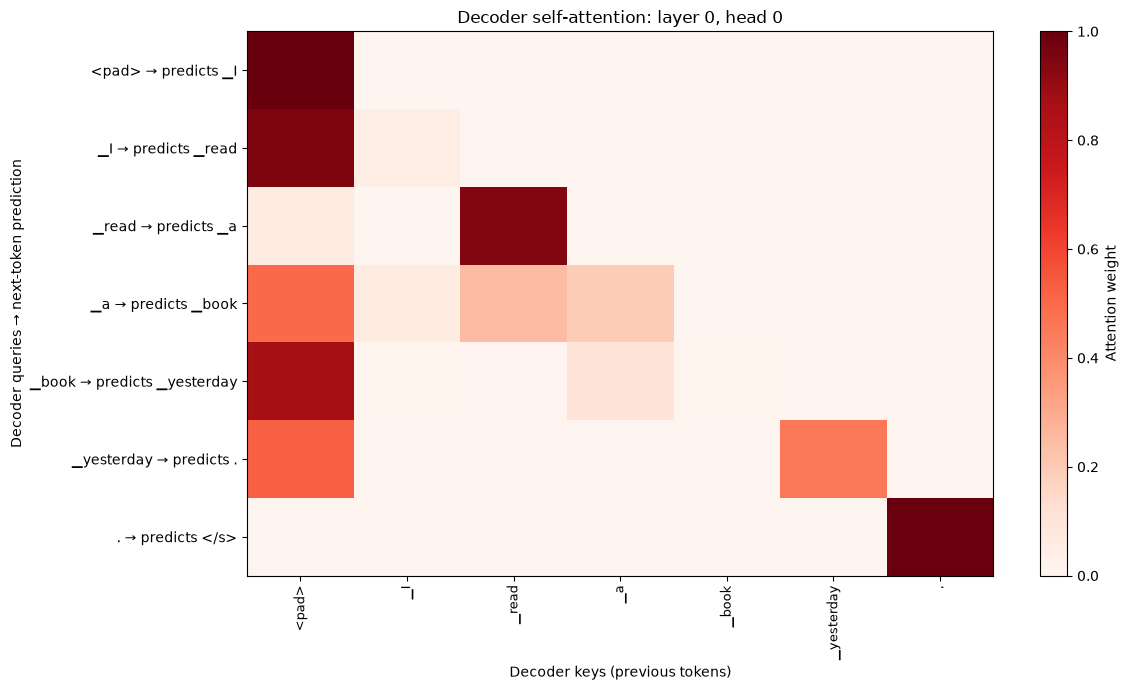

Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [15]:
# Choose layer/head to inspect
GERMAN_LAYER, GERMAN_HEAD = 0, 0

# Decoder self‑attention weights: shape [batch, heads, query_len, key_len]
decoder_weights = german_example['decoder_attention'][GERMAN_LAYER][0, GERMAN_HEAD]

# Labels: each row is a decoder query token → predicted next token
query_labels = [
    f'{query} → predicts {prediction}'
    for query, prediction in zip(
        german_example['decoder_tokens'], german_example['predicted_tokens'])
]

fig, ax = plt.subplots(figsize=(12, 7))

# Plot decoder self‑attention
im = ax.imshow(decoder_weights, cmap='Reds', aspect='auto', vmin=0, vmax=1)

ax.set(
    xticks=range(len(german_example['decoder_tokens'])),
    yticks=range(len(query_labels)),
    xticklabels=german_example['decoder_tokens'],
    yticklabels=query_labels,
    xlabel='Decoder keys (previous tokens)',
    ylabel='Decoder queries → next‑token prediction',
    title=f'Decoder self‑attention: layer {GERMAN_LAYER}, head {GERMAN_HEAD}'
)

plt.setp(ax.get_xticklabels(), rotation=90, fontsize=9)
fig.colorbar(im, ax=ax, label='Attention weight')
plt.tight_layout()
plt.show()

# Sanity checks
print('Row sums:', decoder_weights.sum(-1))
assert torch.allclose(decoder_weights.sum(-1), torch.ones(decoder_weights.shape[0]), atol=1e-5)

# Check causal mask: upper triangle should be zero
assert torch.allclose(
    decoder_weights.triu(1),
    torch.zeros_like(decoder_weights),
    atol=1e-6
)


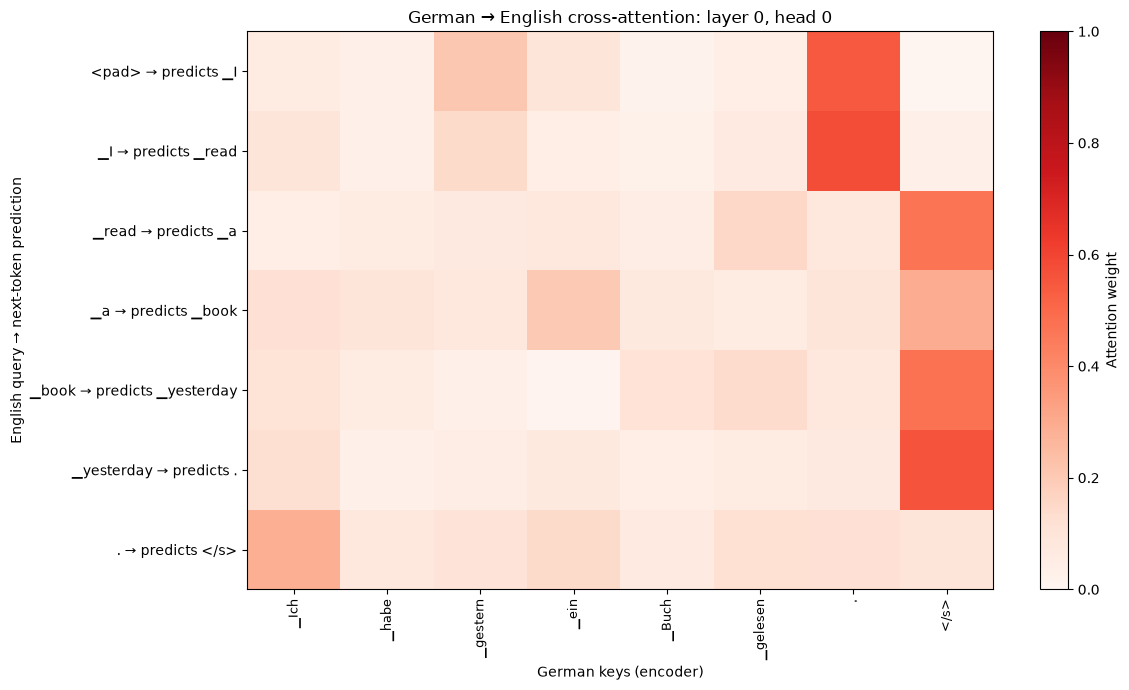

Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


In [16]:
GERMAN_LAYER, GERMAN_HEAD = 0, 0  # Change these to explore other layers/heads.
german_weights = german_example['cross_attention'][GERMAN_LAYER][0, GERMAN_HEAD]
query_labels = [
    f'{query} → predicts {prediction}'
    for query, prediction in zip(
        german_example['decoder_tokens'], german_example['predicted_tokens'])]
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(german_weights, cmap='Reds', aspect='auto', vmin=0, vmax=1)
ax.set(xticks=range(len(german_example['encoder_tokens'])),
       yticks=range(len(query_labels)),
       xticklabels=german_example['encoder_tokens'], yticklabels=query_labels,
       xlabel='German keys (encoder)', ylabel='English query → next-token prediction',
       title=f'German → English cross-attention: layer {GERMAN_LAYER}, head {GERMAN_HEAD}')
plt.setp(ax.get_xticklabels(), rotation=90, fontsize=9)
fig.colorbar(im, ax=ax, label='Attention weight')
plt.tight_layout()
plt.show()
print('Row sums:', german_weights.sum(-1))
assert torch.allclose(german_weights.sum(-1), torch.ones(german_weights.shape[0]), atol=1e-5)
german_decoder_weights = german_example['decoder_attention'][GERMAN_LAYER][0]
assert torch.allclose(german_decoder_weights.triu(1),
                      torch.zeros_like(german_decoder_weights), atol=1e-6)

**Try it:** change the German sentence and rerun this section. Compare at least two heads. Why can cross-attention connect an early English position to a late German position, while decoder self-attention cannot look at future English positions?

### Heads

heads are not really fundementally diffrent from normal attention.
it is ultimatly a question of how many diffrent attention weights do we give each pair

In [17]:
def head_reshape(x, H):
    B, T, D = x.shape                     # (B, T, D)
    return x.reshape(
        B, T, H, D // H                  # (B, T, H, Dh)
    ).transpose(1, 2)                     # (B, H, T, Dh)


def k_head_reshape(x, H):
    B, T, D = x.shape                     # (B, T, D)
    return x.reshape(
        B, T, H, D // H                  # (B, T, H, Dh)
    ).permute(0, 2, 3, 1)                # (B, H, Dh, T)


def attention_math(q, k, v, scale, heads=1, mask=None):
    qh = head_reshape(q, heads)           # (B, H, Tq, Dh)
    kh = k_head_reshape(k, heads)         # (B, H, Dh, Tk)
    vh = head_reshape(v, heads)           # (B, H, Tk, Dh)

    scores = (qh @ kh) * scale            # (B, H, Tq, Tk)

    if mask is not None:
        scores = scores.masked_fill(
            mask, float('-inf')
        )                                 # (B, H, Tq, Tk)

    out = torch.softmax(
        scores, dim=-1
    ) @ vh                                # (B, H, Tq, Dh)

    out = out.transpose(1, 2)             # (B, Tq, H, Dh)
    return out.reshape(q.shape)           # (B, Tq, D)